#### pandas 활용 데이터 전처리 & 시각화
- 외부프로그램 활용 : flourish
- 내부시각화 라이브러리 | 모듈
  - matplotlib : 코드 학습이 꽤 난이도가 있는 편 // 오래됨
  - seaborn : matplotlib를 활용해서 만든 그래프에 색상 및 레이아웃, 프레임 등을 조작할 때 사용
  - plotly : 현존하는 파이썬 데이터 시각화의 가장 최신 트렌드
  - EDA + pandas + plotly : 해당 조합이 가장 최신 데이터 시각화 조합 

#### plotly
1) Plotly Express : px (* 빠르고 간단한 시각화를 할 때 사용)
   - 정말 짧은 코드로 괜찮은 시각적 그래프 출력
   - 학습속도도 빠르고 EDA도 효율적으로 가능
   - 범례 / 2차원 다양한 종류 그래프 / 편집.가공
   - 디테일한 레이아웃 수정, 변경, 커스터마이징은 불가능 
2) Graph Object : go (* 세밀한 커스터마이징 필요할 때 사용)
   - 코드의 길이가 길어짐 / 초심자에게는 어려움
   - 애니메이션, 인터랙티브한 레이블 설정 

In [1]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from plotly import express as px

"""
px.그래프종류(
    데이터프레임,
    x = "x축 열이름",
    y = "y축 열이름",
    title = "그래프 제목"
)

fig.show() # 그래프를 화면에 출력하는 명령어

1) scatter (*산점도)

2) line (* 선)

3) bar (* 막대)

4) histogram (* 히스토그램)

5) box (* 상자그림)
"""

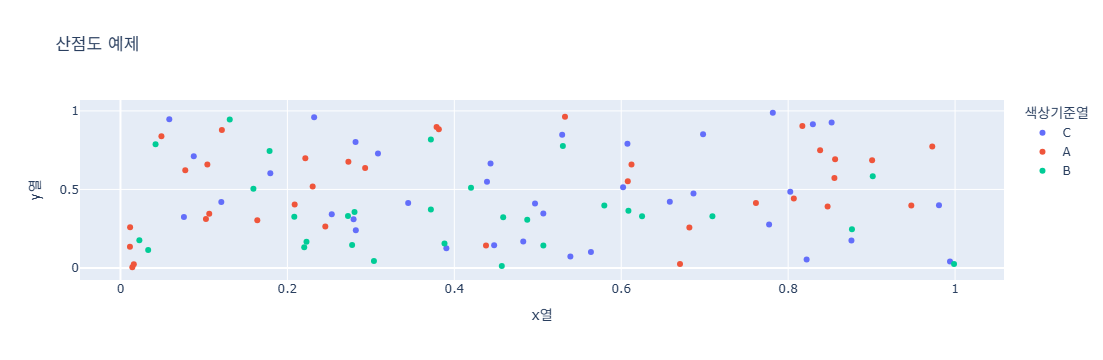

In [6]:
from plotly import express as px
# import plotly.express as px 로도 쓸 수 있음!
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "x열" : np.random.rand(100),   # 0~1 미만의 난수형태의 값을 랜덤으로 생성한다. 
    "y열" : np.random.rand(100),
    "색상기준열" : np.random.choice(["A","B","C"],100),   #색상기준열 안에 들어가는 값은 랜덤이 아니라 직접 선택될 수 있어야 함(?)  
})

fig = px.scatter (
    df,
    x = "x열", 
    y = "y열", 
    color = "색상기준열",
    title = "산점도 예제",
)
fig.show()

#### 산점도 그래프 활용방법
1) 관계분석 : 서로 다른 변수 사이에 상관관계가 존재하는지 파악하고 싶을 때
2) 패턴 및 경향성 파악 : 특정 데이터들이 어떤 패턴이나 경향성을 보이는지 확인하고자 할 때
3) 이상치 (*Outlier) 탐지 : 전체 데이터에서 특정 데이터가 다른 값들과 동떨어진 좌표값 (=이상치)를 가지고 있을 때, 
4) 탐색적 데이터 분석 (*EDA) 초반 단계 : 전체 총 데이터 안에 있는 feature들 간 상관관계 = 상호작용 여부를 판단하고자 할 때

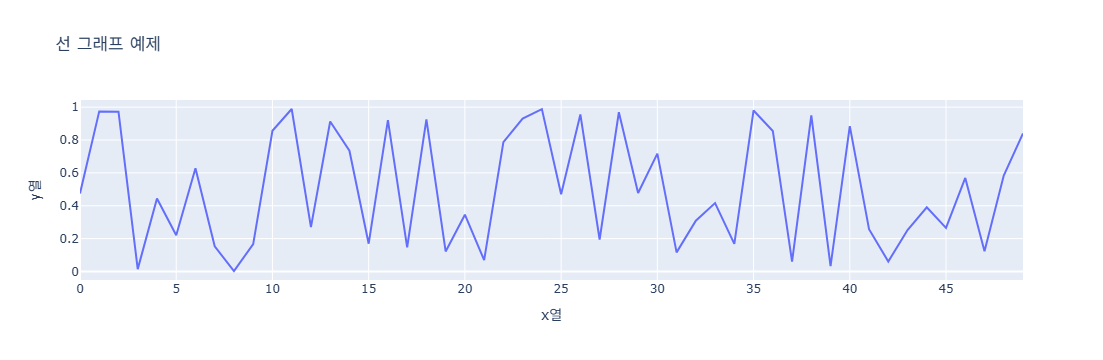

In [7]:
import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "x열" : np.arange(50),   # arange() -> 범위 지정 (0부터 50까지 x좌표값을 쓰겠다.)
    "y열" : np.random.rand(50),
})

fig = px.line(
    df,
    x = "x열",
    y = "y열",
    title = "선 그래프 예제",
)

fig.show()

#### 선 그래프 활용예제
- 선 그래프 : 순차적인 순서에 따른 값의 변화를 선으로 연결해서 보고 싶을 때 사용 

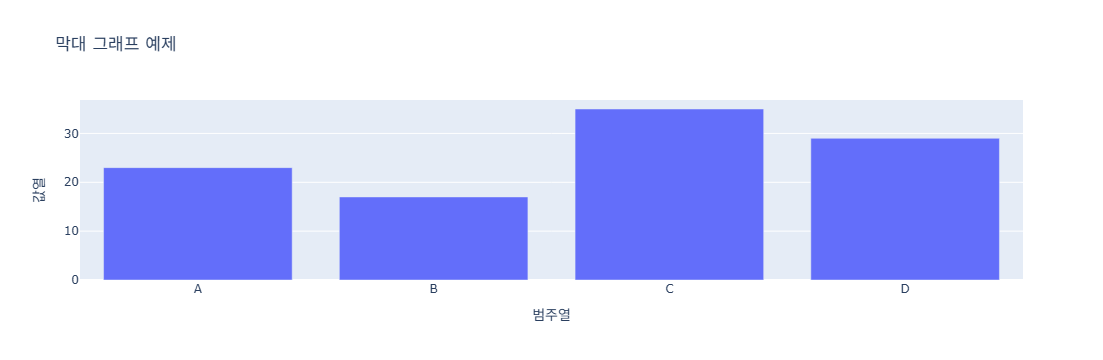

In [9]:
import plotly.express as px
import pandas as pd

df = pd.DataFrame({
    "범주열" : ["A", "B", "C", "D"],
    "값열" : [23, 17, 35, 29]
})

fig = px.bar(
    df,
    x = "범주열",
    y = "값열",
    title = "막대 그래프 예제",
)

fig.show()

#### 막대 그래프 활용 예제
- 범주별 = 범위별 막대의 높이로 비교해서 데이터를 분석 => m/s, 기간별 비교

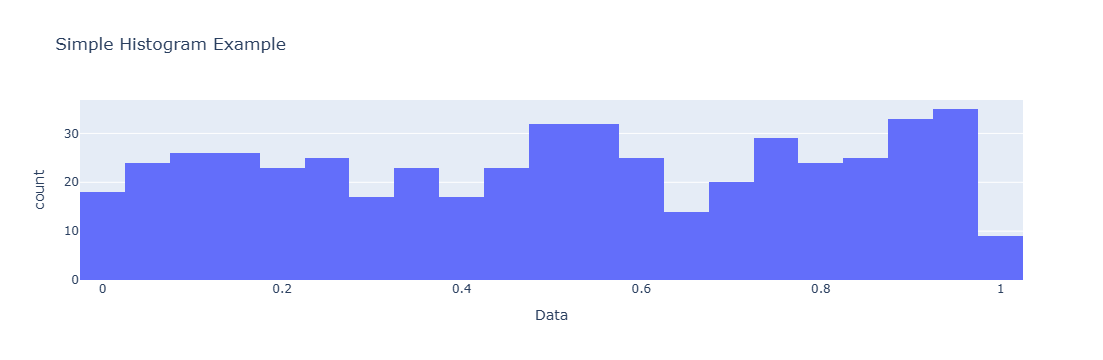

In [10]:
# 히스토그램 => 연속형 데이터의 분포를 구간별 막대로 나타내고자 할 때

import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Data" : np.random.rand(500)
})

fig = px.histogram(
    df,
    x = "Data",
    nbins = 30,   # nbins = number of bins의 약자 // bin => 하나의 구간 또는 막대 하나를 의미 
    title = "Simple Histogram Example"  
)

fig.show()

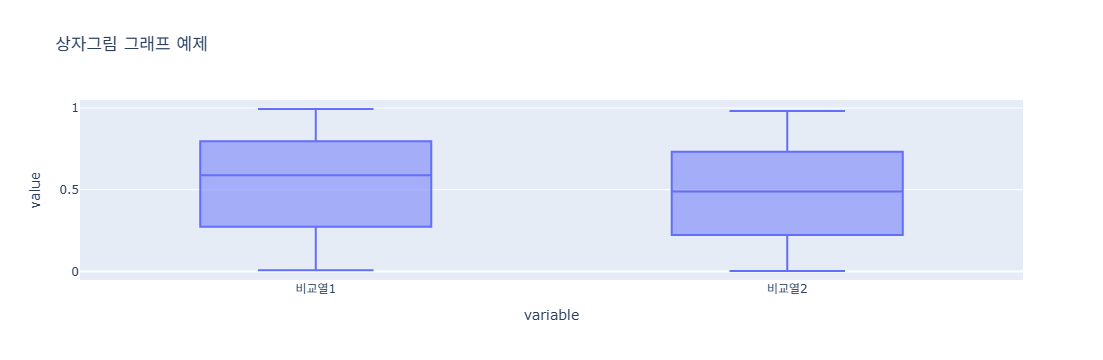

In [11]:
#

import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "비교열1" : np.random.rand(100),
    "비교열2" : np.random.rand(100)
})

fig = px.box(
    df,
    y = ["비교열1", "비교열2"], 
    title = "상자그림 그래프 예제"
)

fig.show()

#### 상자그림 그래프 (Box Plot)
- 여러개의 열의 데이터 분포, 중앙값, 사분위수 및 이상치를 한 눈에 확인 및 비교하고자 할 때 그래프
- 사분위수 계산 :
  Q1 : 데이터의 하위 25%의 값 
  Q3 : 데이터의 상위 25%의 값 
  이상치 : 최저값 0% 미만, 최고값 100% 초과
  => 이상치 값을 계산하기 위한 공식
  => Q3 - Q1 = IQR = Interquartile Range = 사분위 범위
  => 하한 이상치 = Q1 - IQR X 1.5
  => 상한 이상치 = Q3 + IQR X 1.5
  => 하한보다 작은 값이 나왔거나, 상한보다 높은 값이 나왔다 => 특이점 발생
  => 해당 특이점으로부터 발견해야하는 인사이트, 도출해야하는 문제점을 확인하고자 할 때 

In [12]:
# 각 개별 그래프의 세부요소 변경!!!
# 옵션 => 정말 다양하고 버전 업데이트가 빈번하다.
# 1) update_layout() : 해당 그래프에 대한 전체 레이아웃 수정을 하고자 할 때 => 제목, 범례, 여백
# 2) update_xaxes() : x축에 해당되는 속성 요소 수정 => 제목 글꼴, 눈금 등 
# 3) update_yaxes() : y축에 해당되는 속성 요소 수정 => 제목 글꼴, 눈금 등 


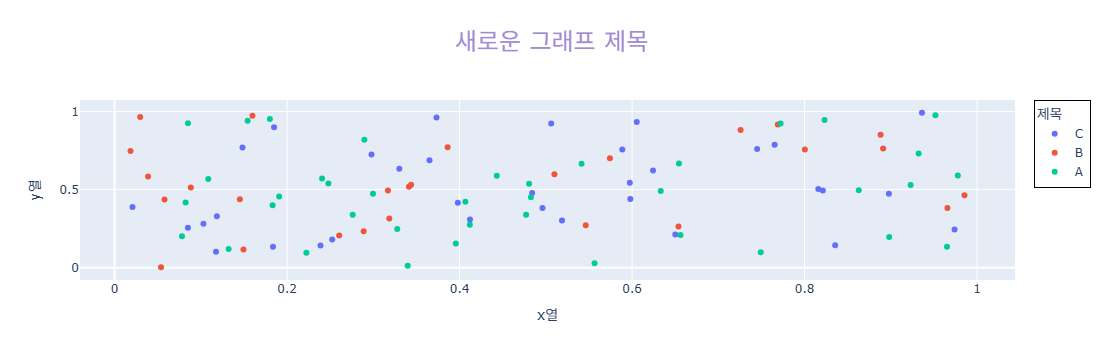

In [25]:
from plotly import express as px
# import plotly.express as px 로도 쓸 수 있음!
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "x열" : np.random.rand(100),   # 0~1 미만의 난수형태의 값을 랜덤으로 생성한다. 
    "y열" : np.random.rand(100),
    "색상기준열" : np.random.choice(["A","B","C"],100),   #색상기준열 안에 들어가는 값은 랜덤이 아니라 직접 선택될 수 있어야 함(?)  
})

fig = px.scatter (
    df,
    x = "x열", 
    y = "y열", 
    color = "색상기준열",
    title = "산점도 예제",
)

fig.update_layout(
    title = {
        "text" : "새로운 그래프 제목",
        "font" : {"size" : 24, "color" : "#a18cd1"},
        "x" : 0.5   # 왼쪽부터 오른쪽 0 -> 1
    },
    # legend = {
    #     "title" : "제목",
    #     "x" : 1.02,
    #     "y" : 1,
    #     "bordercolor" : "#000",   # 테두리 색상
    #     "borderwidth" : 1
    # }
     legend = dict(title = "제목", x = 1.02, y = 1, bordercolor = "black", borderwidth = 1)
)

fig.show()

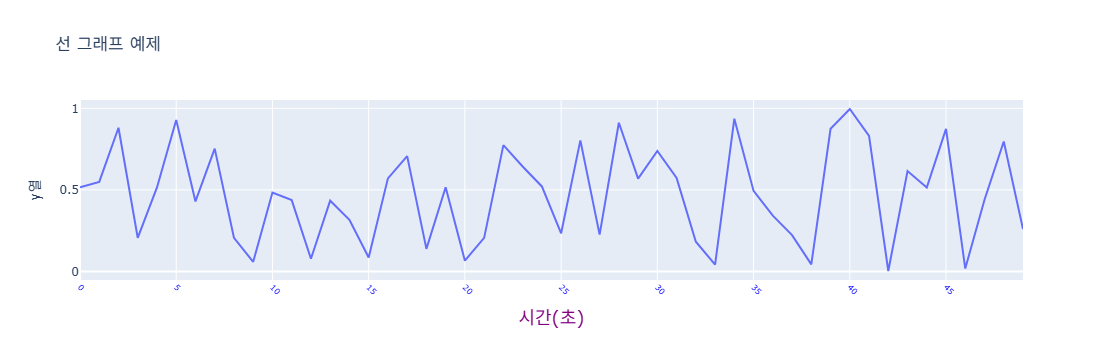

In [31]:
import plotly.express as px
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "x열" : np.arange(50),   # arange() -> 범위 지정 (0부터 50까지 x좌표값을 쓰겠다.)
    "y열" : np.random.rand(50),
})

fig = px.line(
    df,
    x = "x열",
    y = "y열",
    title = "선 그래프 예제",
)

fig.update_xaxes(
    title = "시간(초)",
    # title_font = {
    #     "size" : 18,
    #     "color" : "purple"
    # }
    title_font = dict(size = 18, color = "purple"),
    tickangle = 45,   # 단위의 각도
    # tickfont = {
    #     "size" : 8
    # },
    tickfont = dict(size = 8, color = "#00F"),
    dtick = 5     # 단위 사이의 거리(dtick = 5 = > 0,5,10)
)

fig.show()

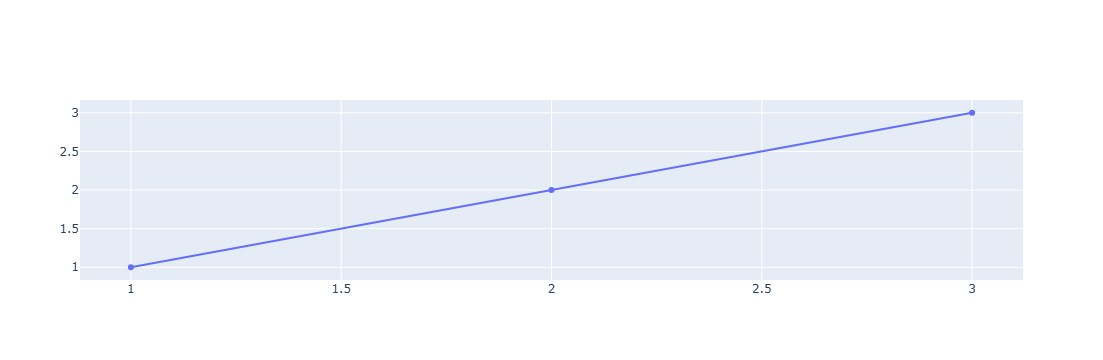

In [32]:
# import plotly.express as px
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x = [1, 2, 3],
        y = [1, 2, 3]
    )
)
# trace => 무언가를 그릴 옵션(?)  // 그래프에 대한 뼈대를 그린다.   (trace = 일종의 그래프라고 생각하기)

fig.update_layout(  #  -> 파이프라인을 만들듯이 세부옵션값들에 대한 
    
)

fig.show()

In [ ]:
1️⃣ go.Scatter(...)

그래프의 종류와 데이터를 정의하는 객체예요.

예를 들어:

go.Scatter → 산점도 / 꺾은선 그래프

go.Bar → 막대그래프

go.Box → 박스플롯

이 안에 x, y, mode, name 같은 데이터와 시각화 방식을 담아요.

즉, "이런 데이터를 이런 방식으로 그려라" 라고 정의하는 단계.
2️⃣ fig.add_trace(...)

Scatter 같은 trace 객체를 Figure에 추가하는 함수예요.

trace = 그래프의 한 레이어(겹)라고 생각하면 돼요.

예시:

fig.add_trace(go.Scatter(...)) → 점/선 그래프 추가

fig.add_trace(go.Bar(...)) → 막대그래프 추가

즉, 그래프에 레이어를 쌓는 단계. (여러 개의 trace를 추가 가능!)

3️⃣ fig.update_layout(...)

전체 그래프의 디자인/레이아웃을 수정하는 함수예요.

데이터 자체는 건드리지 않고, **보이는 형태(외형)**를 꾸며요.

예시:

title="그래프 제목"

xaxis_title="X축 이름"

yaxis_title="Y축 이름"

template="plotly_dark" (테마 변경)

즉, "그려진 그래프의 스타일/옵션"을 조정하는 단계.

✅ 정리 (차이점)

Scatter = 어떤 데이터 + 어떤 타입의 그래프인지 정의

add_trace = 정의한 그래프(trace)를 Figure에 추가

update_layout = 그래프 전체의 스타일(제목, 축, 테마 등) 설정